# Long Short-Term Memory (LSTM) Networks — Companion Notebook

**Lecture:** Introduction to LSTMs (≈30 minutes)
**Goal:** Build an intuition for LSTMs by (1) seeing why vanilla RNNs fail on long sequences, (2) implementing an LSTM cell from scratch in NumPy, and (3) training a real LSTM in PyTorch on a sequence task.

---

## Outline

1. The vanishing-gradient problem in vanilla RNNs (toy NumPy demo).
2. An LSTM cell, written from scratch in NumPy. Forward pass, gate-by-gate.
3. PyTorch example 1: character-level next-character prediction on a tiny corpus.
4. PyTorch example 2: time-series forecasting on a synthetic sine wave.
5. Discussion: when LSTMs still earn their keep in 2026.

> Run cells top-to-bottom. Cells are short on purpose so that you can pause, inspect tensors, and tweak hyperparameters during the lecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
np.set_printoptions(precision=3, suppress=True)

## 1. Why vanilla RNNs struggle: the vanishing gradient

A vanilla RNN updates its hidden state with

$$h_t = \tanh(W_{hh} \, h_{t-1} + W_{xh} \, x_t)$$

When you backpropagate through `T` time steps, the gradient of the loss with respect to an early hidden state contains a product of `T` Jacobians, each shaped like `diag(tanh') · W_hh`. If the largest singular value of that recurrent factor is below 1, the product collapses to zero exponentially in `T`; if it is above 1, it explodes. Either way, learning long-range dependencies becomes impossible.

Below is a minimal demonstration: we feed a length-`T` sequence of zeros (so `tanh' ≈ 1`) and just track how the gradient norm evolves backwards through time.

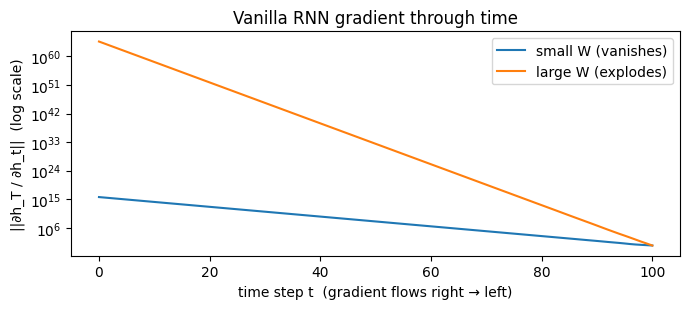

In [2]:
def gradient_norm_through_time(W_hh, T):
    """Return ||dh_T / dh_t|| for t = T, T-1, ..., 0 with x_t = 0."""
    H = W_hh.shape[0]
    g = np.eye(H)              # dh_T / dh_T = I
    norms = [np.linalg.norm(g)]
    for _ in range(T):
        # tanh'(0) = 1, so the Jacobian is just W_hh
        g = g @ W_hh
        norms.append(np.linalg.norm(g))
    return norms[::-1]          # so index 0 == time 0

T = 100
H = 8

W_small = 0.5 * rng.standard_normal((H, H))    # spectral radius < 1 → vanishing
W_large = 1.5 * rng.standard_normal((H, H))    # spectral radius > 1 → exploding

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.semilogy(gradient_norm_through_time(W_small, T), label='small W (vanishes)')
ax.semilogy(gradient_norm_through_time(W_large, T), label='large W (explodes)')
ax.set_xlabel('time step t  (gradient flows right → left)')
ax.set_ylabel('||∂h_T / ∂h_t||  (log scale)')
ax.set_title('Vanilla RNN gradient through time')
ax.legend()
plt.tight_layout(); plt.show()

Notice that the curves are essentially straight lines on a log scale. That is the signature of an exponential. LSTMs were designed to break this exponential by routing information through an additive **cell state** with a learned, near-identity update.

## 2. The LSTM cell, from scratch

An LSTM cell maintains two state vectors: a **cell state** $c_t$ (the long-term memory) and a **hidden state** $h_t$ (the short-term, output-facing memory). At every step it computes four affine transforms of $[h_{t-1}, x_t]$ and squashes them into three gates plus a candidate update.

$$
\begin{aligned}
f_t &= \sigma(W_f [h_{t-1}, x_t] + b_f) && \text{forget gate} \\
i_t &= \sigma(W_i [h_{t-1}, x_t] + b_i) && \text{input gate} \\
\tilde c_t &= \tanh(W_c [h_{t-1}, x_t] + b_c) && \text{candidate} \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde c_t && \text{cell state update} \\
o_t &= \sigma(W_o [h_{t-1}, x_t] + b_o) && \text{output gate} \\
h_t &= o_t \odot \tanh(c_t) && \text{hidden state}
\end{aligned}
$$

The crucial line is `c_t = f_t * c_{t-1} + i_t * c_tilde`. When the forget gate $f_t \approx 1$ and the input gate $i_t \approx 0$, the cell state passes through *unchanged*, and gradients flow back through it without exponential decay. That additive “gradient highway” is the entire trick.

In [3]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

class NumpyLSTMCell:
    """A single LSTM cell, NumPy-only, no autograd."""
    def __init__(self, input_size, hidden_size, seed=0):
        rng = np.random.default_rng(seed)
        scale = 1.0 / np.sqrt(hidden_size)
        # Stack the 4 gate weight matrices for efficiency.
        # Order: [forget, input, candidate, output]
        self.W = scale * rng.standard_normal((4 * hidden_size, input_size + hidden_size))
        self.b = np.zeros(4 * hidden_size)
        # A common trick: bias the forget gate to ~1 at init so the cell state
        # is preserved by default. Speeds up learning a lot.
        self.b[:hidden_size] = 1.0
        self.H = hidden_size

    def step(self, x, h_prev, c_prev):
        z = self.W @ np.concatenate([h_prev, x]) + self.b
        H = self.H
        f = sigmoid(z[0*H:1*H])           # forget gate
        i = sigmoid(z[1*H:2*H])           # input gate
        g = np.tanh(z[2*H:3*H])           # candidate cell update
        o = sigmoid(z[3*H:4*H])           # output gate
        c = f * c_prev + i * g            # new cell state
        h = o * np.tanh(c)                # new hidden state
        return h, c, dict(f=f, i=i, g=g, o=o)

# Run 20 random steps and watch the gates.
cell = NumpyLSTMCell(input_size=3, hidden_size=4, seed=1)
h = np.zeros(cell.H); c = np.zeros(cell.H)
history = []
for _ in range(20):
    x = rng.standard_normal(3)
    h, c, gates = cell.step(x, h, c)
    history.append((c.copy(), gates))

print('Final cell state c =', history[-1][0])
print('Final forget gate f =', history[-1][1]['f'])

Final cell state c = [-0.008  0.18  -0.006  0.042]
Final forget gate f = [0.662 0.78  0.686 0.503]


Let’s visualize one cell-state coordinate over time. The forget gate's average value controls how slowly old information decays.

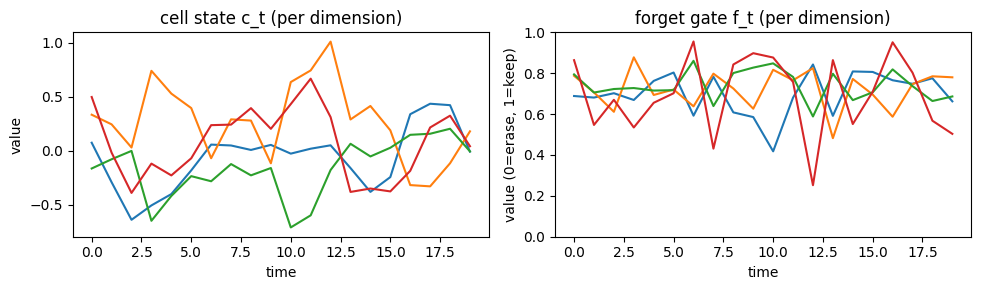

In [4]:
cs = np.stack([h[0] for h in history])     # shape (T, hidden_size)
fs = np.stack([h[1]['f'] for h in history])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(cs); axes[0].set_title('cell state c_t (per dimension)')
axes[0].set_xlabel('time'); axes[0].set_ylabel('value')
axes[1].plot(fs); axes[1].set_title('forget gate f_t (per dimension)')
axes[1].set_xlabel('time'); axes[1].set_ylabel('value (0=erase, 1=keep)')
axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 3. PyTorch example 1 — character-level next-character prediction

We now switch to PyTorch and train a real LSTM on a tiny corpus. The task is the canonical one: given a window of characters, predict the next character. Even on a few sentences the LSTM picks up word boundaries, common bigrams, and punctuation patterns within a couple of minutes on CPU.

In [5]:
import torch
import torch.nn as nn

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cpu


In [6]:
text = (
    "long short term memory networks are a kind of recurrent neural network. "
    "they were introduced in 1997 and are well suited to learning from sequential data "
    "such as text, speech, and time series. an lstm cell uses three gates: "
    "the forget gate, the input gate, and the output gate. "
    "these gates allow the network to remember information across many time steps. "
) * 30   # repeat to give the LSTM enough material

vocab = sorted(set(text))
stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for ch, i in stoi.items()}
V = len(vocab)
print(f'corpus length: {len(text)} chars,  vocab size: {V}')

corpus length: 10680 chars,  vocab size: 30


In [7]:
data = torch.tensor([stoi[c] for c in text], dtype=torch.long, device=device)

SEQ_LEN = 40
BATCH   = 32

def get_batch():
    """Sample BATCH random windows of length SEQ_LEN+1, return (x, y)."""
    ix = torch.randint(0, len(data) - SEQ_LEN - 1, (BATCH,), device=device)
    x = torch.stack([data[i:i+SEQ_LEN]     for i in ix])
    y = torch.stack([data[i+1:i+SEQ_LEN+1] for i in ix])
    return x, y

xb, yb = get_batch()
print('batch shapes:', xb.shape, yb.shape)

batch shapes: torch.Size([32, 40]) torch.Size([32, 40])


In [8]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed=32, hidden=128, layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed)
        self.lstm  = nn.LSTM(embed, hidden, num_layers=layers, batch_first=True)
        self.head  = nn.Linear(hidden, vocab_size)

    def forward(self, x, state=None):
        e = self.embed(x)                  # (B, T, embed)
        out, state = self.lstm(e, state)   # (B, T, hidden)
        logits = self.head(out)            # (B, T, vocab)
        return logits, state

model = CharLSTM(V).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()
n_params = sum(p.numel() for p in model.parameters())
print(f'model has {n_params:,} parameters')

model has 87,774 parameters


step    0  loss 3.398
step  100  loss 0.338
step  200  loss 0.137
step  300  loss 0.106
step  400  loss 0.101
step  500  loss 0.093
step  599  loss 0.092


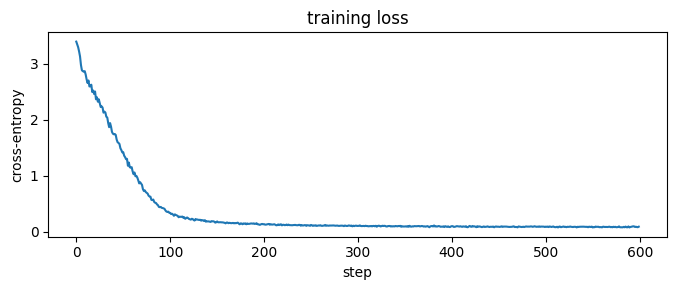

In [9]:
STEPS = 600
losses = []
for step in range(STEPS):
    x, y = get_batch()
    logits, _ = model(x)
    loss = loss_fn(logits.reshape(-1, V), y.reshape(-1))
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # prevent exploding grads
    opt.step()
    losses.append(loss.item())
    if step % 100 == 0 or step == STEPS - 1:
        print(f'step {step:4d}  loss {loss.item():.3f}')

plt.figure(figsize=(7, 3))
plt.plot(losses); plt.xlabel('step'); plt.ylabel('cross-entropy')
plt.title('training loss'); plt.tight_layout(); plt.show()

In [10]:
@torch.no_grad()
def sample(model, prompt='lstm', n_new=200, temperature=0.8):
    model.eval()
    idx = torch.tensor([stoi[c] for c in prompt], dtype=torch.long, device=device)[None, :]
    state = None
    out = list(prompt)
    # First, feed the prompt through to build up state.
    logits, state = model(idx, state)
    last = logits[:, -1, :]
    for _ in range(n_new):
        probs = torch.softmax(last / temperature, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        out.append(itos[next_id.item()])
        logits, state = model(next_id, state)
        last = logits[:, -1, :]
    return ''.join(out)

print(sample(model, prompt='lstm cells ', n_new=300))

lstm cells tal dat output gate. these gates allow the network to remember information across many time steps. long short term memory networks are a kind of recurrent neural network. they were introduced in 1997 and are well suited to learning from sequential data such as text, speech, and time series. an lstm 


The output won't be Shakespeare. With this much data and this little training, you should expect to see *real words from the corpus, glued together by plausible spaces and the occasional period*. That alone is more than a bigram model can do, because the LSTM has learned to carry state across many characters.

## 4. PyTorch example 2 — time-series forecasting on a sine wave

Sequence-to-one prediction is the LSTM's bread and butter. Here we generate a noisy sine wave and ask the network to predict the next value from a window of the previous 20.

In [11]:
T = 1000
t = np.linspace(0, 60, T)
series = np.sin(t) + 0.3 * np.sin(2.7 * t) + 0.1 * rng.standard_normal(T)

WIN = 20
X = np.stack([series[i:i+WIN]   for i in range(T - WIN - 1)])
Y = np.array  ([series[i+WIN]    for i in range(T - WIN - 1)])

# 80/20 train/test split, no shuffling — order matters in time series
split = int(0.8 * len(X))
X_tr, X_te = X[:split], X[split:]
Y_tr, Y_te = Y[:split], Y[split:]

X_tr = torch.tensor(X_tr, dtype=torch.float32, device=device).unsqueeze(-1)  # (N, T, 1)
Y_tr = torch.tensor(Y_tr, dtype=torch.float32, device=device)
X_te = torch.tensor(X_te, dtype=torch.float32, device=device).unsqueeze(-1)
Y_te = torch.tensor(Y_te, dtype=torch.float32, device=device)

print('train:', X_tr.shape, Y_tr.shape, '   test:', X_te.shape, Y_te.shape)

train: torch.Size([783, 20, 1]) torch.Size([783])    test: torch.Size([196, 20, 1]) torch.Size([196])


In [12]:
class Forecaster(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)   # use only the final hidden state

f_model = Forecaster().to(device)
f_opt   = torch.optim.Adam(f_model.parameters(), lr=5e-3)
f_loss  = nn.MSELoss()

EPOCHS = 80
BATCH  = 64
for epoch in range(EPOCHS):
    perm = torch.randperm(len(X_tr), device=device)
    epoch_loss = 0.0
    for i in range(0, len(X_tr), BATCH):
        idx = perm[i:i+BATCH]
        pred = f_model(X_tr[idx])
        loss = f_loss(pred, Y_tr[idx])
        f_opt.zero_grad(); loss.backward(); f_opt.step()
        epoch_loss += loss.item() * len(idx)
    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f'epoch {epoch:3d}  train MSE {epoch_loss/len(X_tr):.4f}')

epoch   0  train MSE 0.3505
epoch  10  train MSE 0.0164
epoch  20  train MSE 0.0155
epoch  30  train MSE 0.0164
epoch  40  train MSE 0.0150
epoch  50  train MSE 0.0153
epoch  60  train MSE 0.0150
epoch  70  train MSE 0.0151
epoch  79  train MSE 0.0151


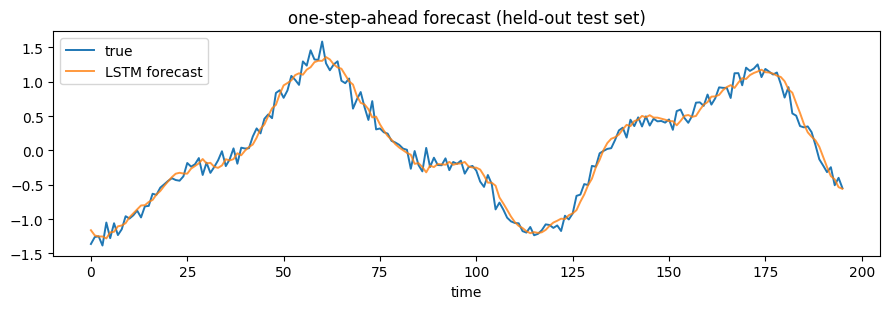

test MSE = 0.0139


In [13]:
f_model.eval()
with torch.no_grad():
    pred_te = f_model(X_te).cpu().numpy()
true_te = Y_te.cpu().numpy()

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(true_te, label='true', linewidth=1.4)
ax.plot(pred_te, label='LSTM forecast', linewidth=1.4, alpha=0.8)
ax.set_title('one-step-ahead forecast (held-out test set)')
ax.set_xlabel('time'); ax.legend()
plt.tight_layout(); plt.show()

mse = float(((pred_te - true_te) ** 2).mean())
print(f'test MSE = {mse:.4f}')

## 5. So when should you actually use an LSTM in 2026?

Transformers have largely replaced LSTMs for language modelling. But LSTMs still have real strengths:

- **Streaming / online inference.** State is `O(hidden)` per step, regardless of how long the sequence has been running. Transformers need a growing KV cache.
- **Tiny models on edge devices.** A 2-layer, 64-hidden LSTM is a few hundred KB and runs comfortably on a microcontroller.
- **Strong inductive bias for time series.** When you have modest data and roughly stationary dynamics, an LSTM often beats a Transformer of similar size.
- **Long-context efficiency.** Inference is `O(T)` rather than `O(T²)`. Recent variants such as xLSTM, Mamba, and other state-space models build directly on this idea.

## Exercises

1. In the gradient demo, replace `W_hh` with an orthogonal matrix (use `np.linalg.qr`). What happens to the gradient norm?
2. In the `NumpyLSTMCell`, set the forget-gate bias to `0` instead of `1` and rerun. Does the cell state still drift smoothly?
3. In the character model, swap `nn.LSTM` for `nn.GRU`. How does the loss curve change for the same training budget?
4. In the forecasting example, add a second LSTM layer (`num_layers=2`) and dropout (`dropout=0.2`). Does test MSE improve?